In [ ]:
import os

os.chdir('/Users/joszenda/stock-market-analysis')

os.makedirs('data', exist_ok=True)
os.makedirs('dashboard', exist_ok=True)
os.makedirs('sql', exist_ok=True)

print('Folder roboczy:', os.getcwd())
print('Pliki:', os.listdir('.'))

Folder roboczy: /Users/joszenda/stock-market-analysis
Pliki: ['requirements.txt', 'README.md', 'dashboard', '.gitignore', 'venv', '.git', 'data', 'notebooks', 'sql']


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Biblioteki załadowane ')

Biblioteki załadowane ✅


In [ ]:

df = pd.read_csv('data/stock_data.csv')

print(f'Rozmiar datasetu: {df.shape}')
print(f'Kolumny: {df.columns.tolist()}')
df.head()

Rozmiar datasetu: (5000, 8)
Kolumny: ['date', 'company', 'open_price', 'high_price', 'low_price', 'close_price', 'volume', 'market_sentiment']


,date,company,open_price,high_price,low_price,close_price,volume,market_sentiment
0,2015-01-01,Tesla,1305.33,75.86,966.61,1457.35,25927814,Bearish
1,2015-01-02,Google,391.80,686.82,593.58,883.22,22040434,Neutral
2,2015-01-03,Netflix,985.74,1275.50,1253.30,1131.63,36551427,Bullish
3,2015-01-04,Amazon,514.78,299.75,441.69,222.58,43823086,Bullish
4,2015-01-05,Amazon,779.04,657.66,1301.97,1453.85,38410461,Neutral


In [ ]:

print('=== Brakujące wartości ===')
print(df.isnull().sum())

print('\n=== Typy danych ===')
print(df.dtypes)

print('\n=== Podstawowe statystyki ===')
df.describe()

=== Brakujące wartości ===
date                0
company             0
open_price          0
high_price          0
low_price           0
close_price         0
volume              0
market_sentiment    0
dtype: int64

=== Typy danych ===
date                    str
company                 str
open_price          float64
high_price          float64
low_price           float64
close_price         float64
volume                int64
market_sentiment        str
dtype: object

=== Podstawowe statystyki ===


,open_price,high_price,low_price,close_price,volume
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,772.708202,811.990270,743.705270,777.440598,2.496821e+07
std,413.510336,433.521016,405.299947,420.683862,1.441834e+07
min,50.550000,55.160000,45.420000,50.200000,1.050690e+05
25%,414.967500,436.285000,392.562500,406.497500,1.245287e+07
50%,771.950000,819.575000,742.910000,787.085000,2.520512e+07
75%,1136.812500,1187.797500,1093.585000,1140.910000,3.729874e+07
max,1499.520000,1549.740000,1448.970000,1499.450000,4.999939e+07


In [ ]:

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['company', 'date']).reset_index(drop=True)
df = df.drop_duplicates()
df = df.dropna()

# Nowe kolumny
df['daily_return'] = df.groupby('company')['close_price'].pct_change() * 100
df['price_range']  = df['high_price'] - df['low_price']
df['month']        = df['date'].dt.to_period('M').astype(str)
df['year']         = df['date'].dt.year

print(f'Czyste dane: {df.shape}')
df.head()

Czyste dane: (5000, 12)


,date,company,open_price,high_price,low_price,close_price,volume,market_sentiment,daily_return,price_range,month,year
0,2015-01-04,Amazon,514.78,299.75,441.69,222.58,43823086,Bullish,NaN,-141.94,2015-01,2015
1,2015-01-05,Amazon,779.04,657.66,1301.97,1453.85,38410461,Neutral,553.180879,-644.31,2015-01,2015
2,2015-01-20,Amazon,1372.24,1004.11,1061.16,995.23,36111152,Bullish,-31.545208,-57.05,2015-01,2015
3,2015-01-23,Amazon,347.79,433.18,121.05,1170.53,5455226,Bullish,17.614019,312.13,2015-01,2015
4,2015-01-31,Amazon,1064.43,838.63,900.94,1478.93,40446060,Neutral,26.347039,-62.31,2015-01,2015


In [ ]:

df.to_csv('data/stock_clean.csv', index=False)
print('Zapisano data/stock_clean.csv ')

Zapisano data/stock_clean.csv ✅


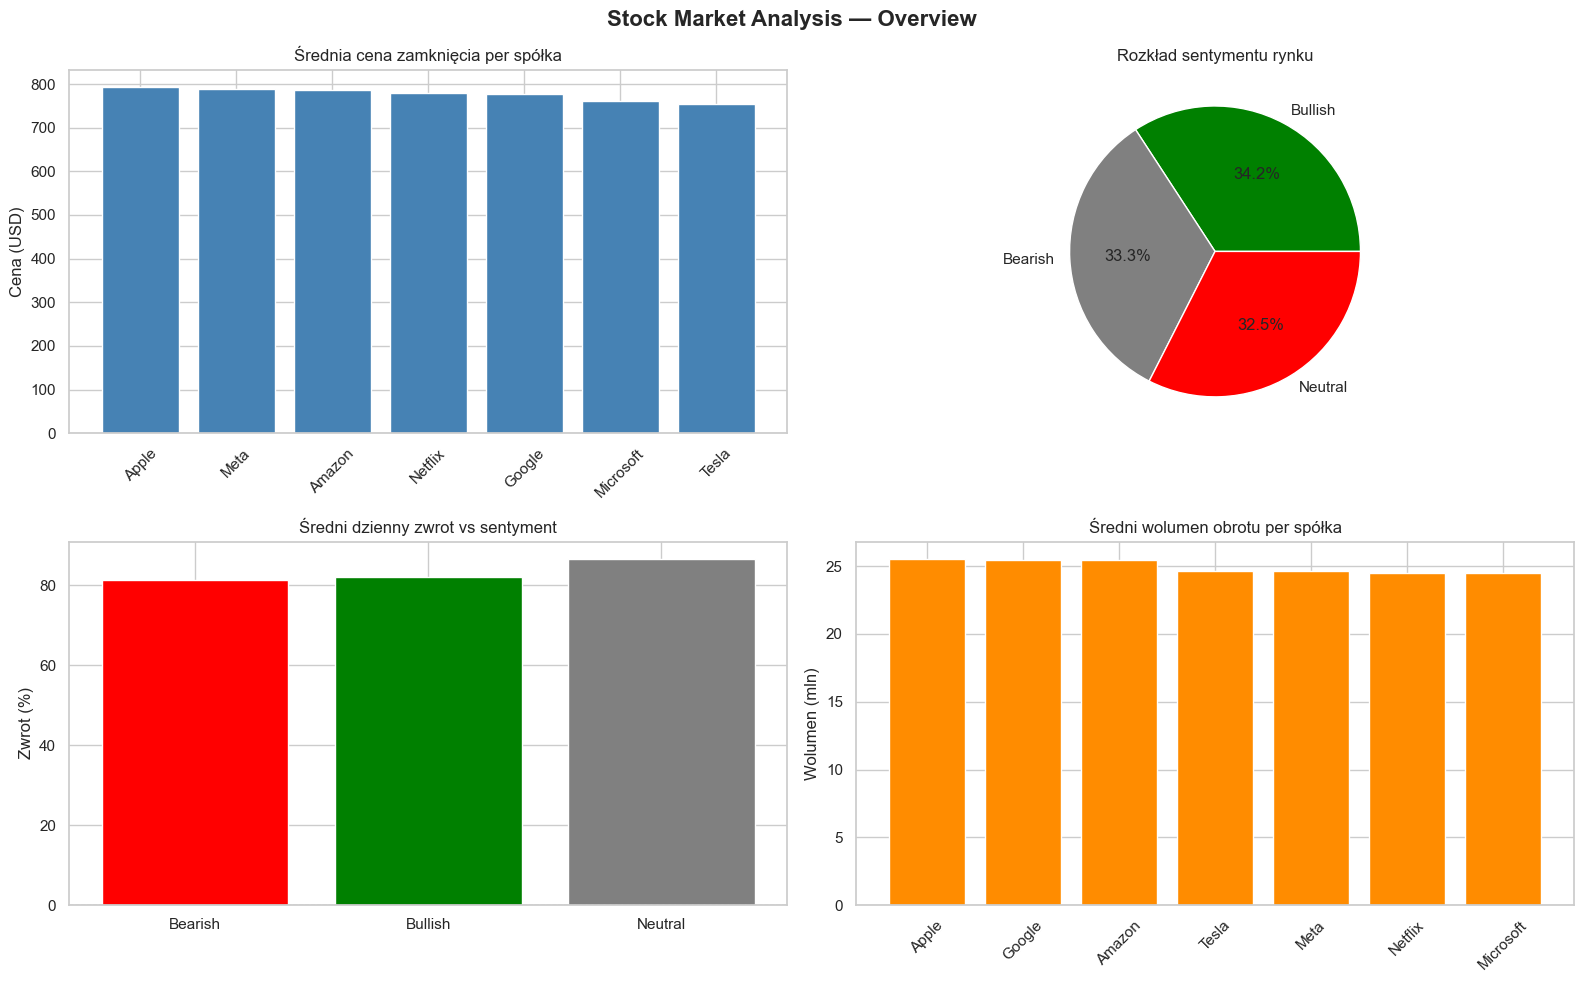

Zapisano dashboard/analysis_overview.png ✅


In [17]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stock Market Analysis — Overview', fontsize=16, fontweight='bold')

# 1. Średnia cena zamknięcia per spółka
avg_close = df.groupby('company')['close_price'].mean().sort_values(ascending=False)
axes[0, 0].bar(avg_close.index, avg_close.values, color='steelblue')
axes[0, 0].set_title('Średnia cena zamknięcia per spółka')
axes[0, 0].set_ylabel('Cena (USD)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Rozkład sentymentu
sentiment_counts = df['market_sentiment'].value_counts()
axes[0, 1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=['green', 'gray', 'red']
)
axes[0, 1].set_title('Rozkład sentymentu rynku')

# 3. Średni dzienny zwrot vs sentyment
sentiment_return = df.groupby('market_sentiment')['daily_return'].mean()
colors_map = {'Bullish': 'green', 'Neutral': 'gray', 'Bearish': 'red'}
bar_colors = [colors_map.get(s, 'steelblue') for s in sentiment_return.index]
axes[1, 0].bar(sentiment_return.index, sentiment_return.values, color=bar_colors)
axes[1, 0].set_title('Średni dzienny zwrot vs sentyment')
axes[1, 0].set_ylabel('Zwrot (%)')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# 4. Średni wolumen per spółka
avg_volume = df.groupby('company')['volume'].mean().sort_values(ascending=False)
axes[1, 1].bar(avg_volume.index, avg_volume.values / 1e6, color='darkorange')
axes[1, 1].set_title('Średni wolumen obrotu per spółka')
axes[1, 1].set_ylabel('Wolumen (mln)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('dashboard/analysis_overview.png', dpi=150)
plt.show()
print('Zapisano dashboard/analysis_overview.png ✅')

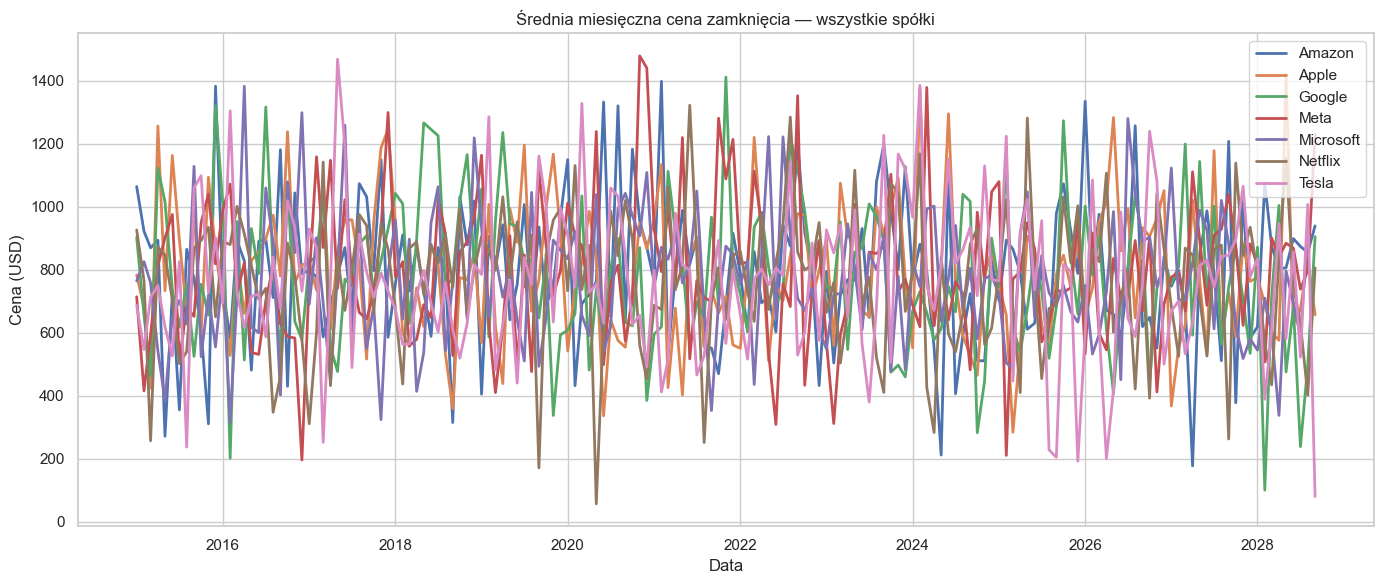

Zapisano dashboard/price_trends_monthly.png ✅


In [ ]:

monthly = df.groupby(['company', 'month'])['close_price'].mean().reset_index()
monthly['month'] = pd.to_datetime(monthly['month'])

plt.figure(figsize=(14, 6))
for company in monthly['company'].unique():
    data = monthly[monthly['company'] == company]
    plt.plot(data['month'], data['close_price'], label=company, linewidth=2)

plt.title('Średnia miesięczna cena zamknięcia — wszystkie spółki')
plt.xlabel('Data')
plt.ylabel('Cena (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('dashboard/price_trends_monthly.png', dpi=150)
plt.show()
print('Zapisano dashboard/price_trends_monthly.png ✅')

In [16]:

con = duckdb.connect()
con.execute("CREATE TABLE stocks AS SELECT * FROM 'data/stock_clean.csv'")

result1 = con.execute("""
    SELECT
        company,
        ROUND(AVG(close_price), 2)  AS avg_close,
        ROUND(MAX(close_price), 2)  AS max_close,
        ROUND(MIN(close_price), 2)  AS min_close,
        ROUND(AVG(volume)/1e6, 2)   AS avg_volume_mln
    FROM stocks
    GROUP BY company
    ORDER BY avg_close DESC
""").df()

print('=== Statystyki per spółka ===')
result1

=== Statystyki per spółka ===


,company,avg_close,max_close,min_close,avg_volume_mln
0,Apple,793.31,1499.45,50.59,25.53
1,Meta,788.17,1494.33,50.58,24.64
2,Amazon,786.39,1498.25,54.65,25.46
3,Netflix,779.63,1498.12,53.59,24.52
4,Google,777.49,1498.48,54.48,25.48
5,Microsoft,761.25,1498.98,50.20,24.48
6,Tesla,753.63,1497.72,56.82,24.67


In [19]:

result2 = con.execute("""
    SELECT
        market_sentiment,
        ROUND(AVG(daily_return), 3) AS avg_daily_return,
        COUNT(*)                    AS records_number
    FROM stocks
    WHERE daily_return IS NOT NULL
    GROUP BY market_sentiment
    ORDER BY avg_daily_return DESC
""").df()

print('=== Sentyment vs średni zwrot dzienny ===')
result2

=== Sentyment vs średni zwrot dzienny ===


,market_sentiment,avg_daily_return,records_number
0,Neutral,86.543,1623
1,Bullish,81.985,1706
2,Bearish,81.232,1664


In [14]:

result3 = con.execute("""
    SELECT
        company,
        date,
        ROUND(daily_return, 2) AS daily_return_pct,
        market_sentiment
    FROM stocks
    WHERE daily_return IS NOT NULL
    ORDER BY daily_return DESC
    LIMIT 10
""").df()

print('=== Top 10 dni z największym zwrotem ===')
result3

=== Top 10 dni z największym zwrotem ===


,company,date,daily_return_pct,market_sentiment
0,Microsoft,2024-11-11,2594.29,Bearish
1,Apple,2027-12-07,2536.51,Bullish
2,Netflix,2026-08-17,2488.34,Bearish
3,Microsoft,2019-04-12,2414.40,Bullish
4,Microsoft,2016-05-19,2332.36,Bearish
5,Tesla,2016-05-28,2321.41,Bearish
6,Apple,2020-03-05,2302.42,Neutral
7,Apple,2016-07-13,2286.89,Neutral
8,Netflix,2022-03-14,2282.18,Neutral
9,Google,2019-12-27,2248.40,Bullish
